#Task Description
**Task**
- Build a machine learning model that classifies tweets as disaster-related or not disaster-related.
- The goal is to apply NLP techniques (text preprocessing, embeddings, feature engineering, deep learning, etc.) to detect whether a tweet refers to a real-world disaster.

**Training Data Provided**
- Contains **7,613 tweets** labeled with target (1 = disaster, 0 = not disaster).
- Includes metadata fields:
- id: unique identifier for each tweet
- text: the tweet content (main feature for classification)
- keyword: specific word associated with the tweet (may be missing)
- location: geographical info (may be missing)

**Testing Data**
- Contains **3,263 tweets**. Data includes the same columns as the training set, except 'target'.

#Loading Data
In this step, the dataset was downloaded directly using the Kaggle library. To enable this, a Kaggle API key must be generated and placed in the designated folder. Appropriate file permissions should then be set to ensure successful authentication. Finally, before downloading the data, you must join the competition from your Kaggle account.

In [ ]:
!chmod 600 /root/.config/kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c nlp-getting-started

  0% 0.00/593k [00:00<?, ?B/s]
100% 593k/593k [00:00<00:00, 614MB/s]


In [ ]:
import os

output_dir = 'nlp_data'
zip_file_path = '/content/nlp-getting-started.zip'

# Create the output directory if it doesn't exist
!mkdir -p {output_dir}

# Unzip the file into the specified directory
!unzip {zip_file_path} -d {output_dir}

Archive:  /content/nlp-getting-started.zip
replace nlp_data/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: nlp_data/sample_submission.csv  
replace nlp_data/test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: nlp_data/test.csv       
replace nlp_data/train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: nlp_data/train.csv      


#Exploratory Data Analysis
First, we save the training and testing data into their respective dataframes. Next, we examine the raw data, verify the shape of the tables, and review statistics on missing values. The results align with the dataset description: both the text and target columns are present for every tweet. Therefore, we cannot conclude that any data is incomplete or represents an outlier.

In [ ]:
import pandas as pd

train_df = pd.read_csv('/content/nlp_data/train.csv')

print("\nFirst 5 rows of the DataFrame:")
print(train_df.head())

print("\nDataFrame Info:")
train_df.info()

print("\nDescriptive Statistics:")
print(train_df.describe(include='all'))


First 5 rows of the DataFrame:
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 29

In [ ]:
test_df = pd.read_csv('/content/nlp_data/test.csv')

print("\nFirst 5 rows of the DataFrame:")
print(test_df.head())

print("\nDataFrame Info:")
test_df.info()

print("\nDescriptive Statistics:")
print(test_df.describe(include='all'))


First 5 rows of the DataFrame:
   id keyword location                                               text
0   0     NaN      NaN                 Just happened a terrible car crash
1   2     NaN      NaN  Heard about #earthquake is different cities, s...
2   3     NaN      NaN  there is a forest fire at spot pond, geese are...
3   9     NaN      NaN           Apocalypse lighting. #Spokane #wildfires
4  11     NaN      NaN      Typhoon Soudelor kills 28 in China and Taiwan

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        3263 non-null   int64 
 1   keyword   3237 non-null   object
 2   location  2158 non-null   object
 3   text      3263 non-null   object
dtypes: int64(1), object(3)
memory usage: 102.1+ KB

Descriptive Statistics:
                  id  keyword  location  \
count    3263.000000     3237      2158   
unique    

##Keywords
Some observations:
- Keywords appear to be a potentially strong predictor of the disaster/non-disaster class, as the top 10 keywords from each class show little overlap.
- It is reasonable to assume that authors tend to select keywords commonly used by others to describe the same event. For example, if tweet A contains keyword B and refers to a real disaster, then tweet C that also uses keyword B is likely to describe a real disaster as well.
- However, many keywords are unique, so this conditional probability rule may only apply to a relatively small subset of tweets associated with a given keyword.
- At first glance, there does not appear to be a strong correlation between the literal meaning of a keyword and its likelihood of indicating a disaster. For instance, some non-disaster tweets include keywords such as “armageddon”, “ruin”, and “wrecked”, which could easily be misinterpreted as disaster-related without additional context.

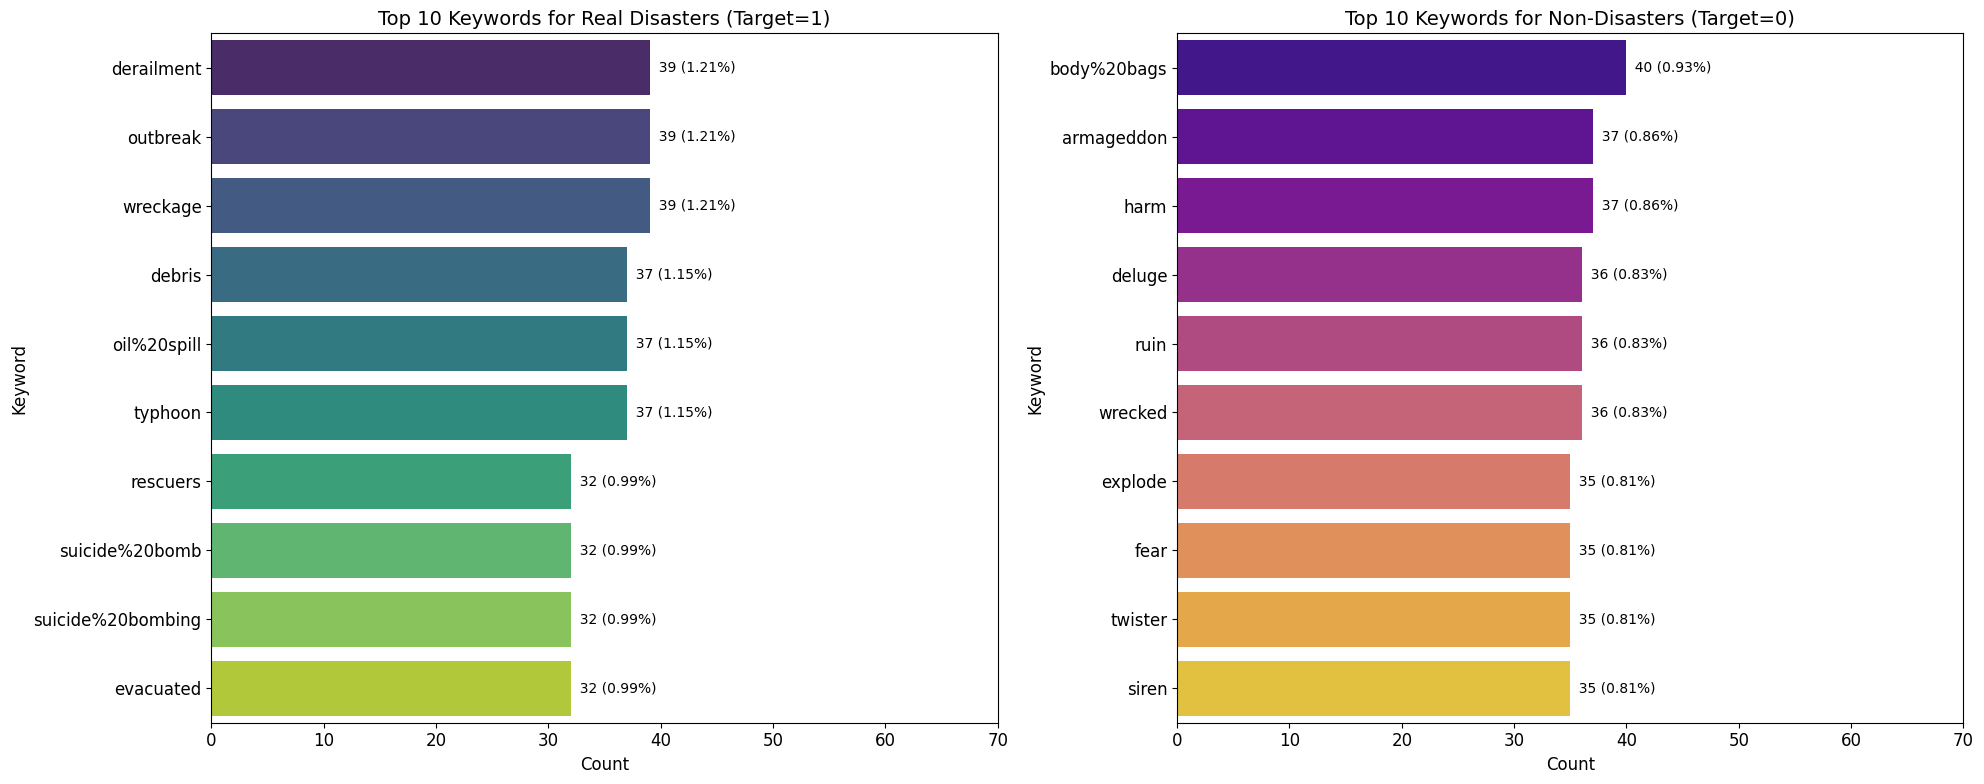

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a larger default font size for better readability
plt.rcParams.update({'font.size': 12})

# Prepare data for plotting for target=1
keywords_1 = top_10_keywords_real_disasters.index
counts_1 = top_10_keywords_real_disasters.values
percentages_1 = percentages_top_10_real_disasters.values
labels_1 = [f'{k} ({c}, {p:.2f}%)' for k, c, p in zip(keywords_1, counts_1, percentages_1)]

# Prepare data for plotting for target=0
keywords_0 = top_10_keywords_non_disasters.index
counts_0 = top_10_keywords_non_disasters.values
percentages_0 = percentages_top_10_non_disasters.values
labels_0 = [f'{k} ({c}, {p:.2f}%)' for k, c, p in zip(keywords_0, counts_0, percentages_0)]

# Create the figure and a set of subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Set x-axis limits for both subplots to 70 for visual compactness and consistency
for ax in axes:
    ax.set_xlim(0, 70)

# Plot for target=1 (Real Disasters)
sns.barplot(x=counts_1, y=keywords_1, ax=axes[0], palette='viridis', hue=keywords_1, legend=False)
axes[0].set_title('Top 10 Keywords for Real Disasters (Target=1)', fontsize=14)
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_ylabel('Keyword', fontsize=12)
for index, value in enumerate(counts_1):
    axes[0].text(value, index, f'  {value} ({percentages_1[index]:.2f}%)', fontsize=10, va='center')

# Plot for target=0 (Non-Disasters)
sns.barplot(x=counts_0, y=keywords_0, ax=axes[1], palette='plasma', hue=keywords_0, legend=False)
axes[1].set_title('Top 10 Keywords for Non-Disasters (Target=0)', fontsize=14)
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_ylabel('Keyword', fontsize=12)
for index, value in enumerate(counts_0):
    axes[1].text(value, index, f'  {value} ({percentages_0[index]:.2f}%)', fontsize=10, va='center')

plt.tight_layout()
plt.show()

##Location
Observations:
- The `location` field appears to be manually entered by users rather than drawn from a standardized list. As a result, the same country can be represented in multiple ways (e.g., *“USA”* vs. *“United States”*), and cities, states, and countries are intermixed. Notably, one of the top entries is simply *“Everywhere.”*
- The `location` field does not seem useful for the classification task. For example, two identical tweets—one tagged with *“USA”* and the other with *“San Francisco”*—should be classified in the same way regardless of location. To ensure this consistency, we **removed the location column from the training set**.


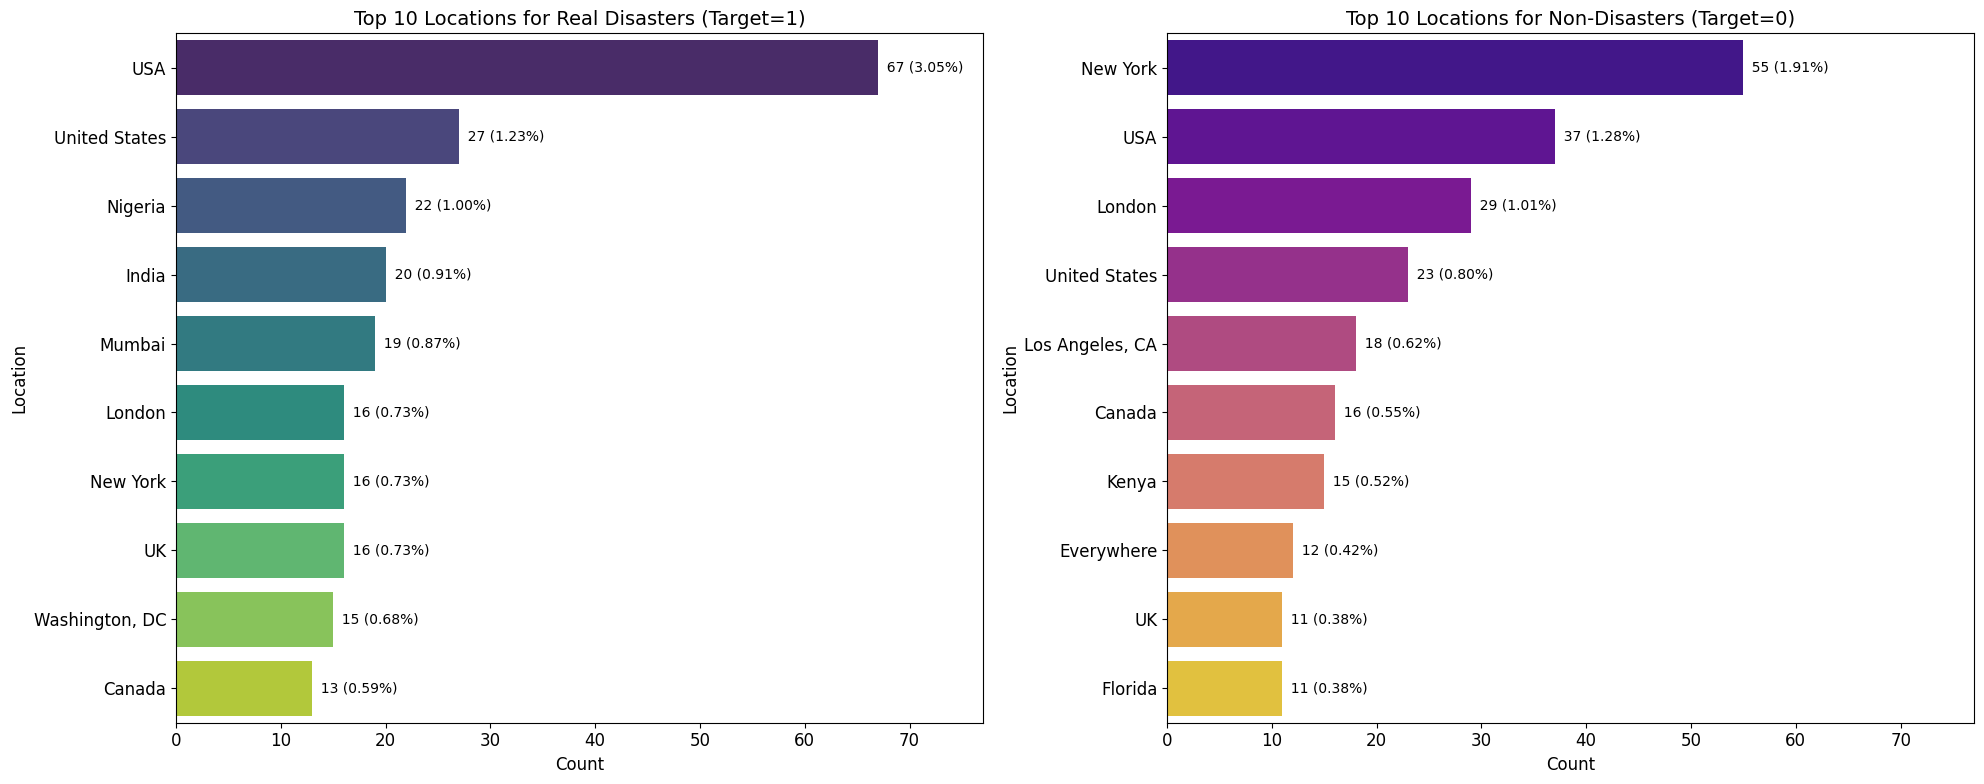

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a larger default font size for better readability
plt.rcParams.update({'font.size': 12})

# Prepare data for plotting for target=1 (Real Disasters)
locations_1 = top_10_locations_real_disasters.index
counts_1 = top_10_locations_real_disasters.values
percentages_1 = percentages_top_10_real_disasters.values

# Prepare data for plotting for target=0 (Non-Disasters)
locations_0 = top_10_locations_non_disasters.index
counts_0 = top_10_locations_non_disasters.values
percentages_0 = percentages_top_10_non_disasters.values

# Create the figure and a set of subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Determine max count for setting consistent x-axis limits
max_count = max(counts_1.max(), counts_0.max()) + 10 # Add some buffer

# Plot for target=1 (Real Disasters)
sns.barplot(x=counts_1, y=locations_1, ax=axes[0], palette='viridis', hue=locations_1, legend=False)
axes[0].set_title('Top 10 Locations for Real Disasters (Target=1)', fontsize=14)
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_ylabel('Location', fontsize=12)
axes[0].set_xlim(0, max_count)
for index, value in enumerate(counts_1):
    axes[0].text(value, index, f'  {value} ({percentages_1[index]:.2f}%)', fontsize=10, va='center')

# Plot for target=0 (Non-Disasters)
sns.barplot(x=counts_0, y=locations_0, ax=axes[1], palette='plasma', hue=locations_0, legend=False)
axes[1].set_title('Top 10 Locations for Non-Disasters (Target=0)', fontsize=14)
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_ylabel('Location', fontsize=12)
axes[1].set_xlim(0, max_count)
for index, value in enumerate(counts_0):
    axes[1].text(value, index, f'  {value} ({percentages_0[index]:.2f}%)', fontsize=10, va='center')

plt.tight_layout()
plt.show()

##Tweet Length
Anticipating extensive text cleaning, tweet length was assessed by character count rather than word count. The initial **expectation was that disaster-related tweets would be shorter than non-disaster tweets**, under the assumption that people rushing to share urgent information might compose briefer messages.

**However, the data did not support this hypothesis**. On average, disaster-related tweets contained 108 characters, which is 12 characters longer than non-disaster tweets. A histogram of character length distributions for the two classes also showed no significant difference, further confirming the lack of separation based on tweet length.

This dataset appears to originate from the era of SMS-style long tweets, when message length was constrained by system limits. As a result, there was likely no practical tendency for disaster-related tweets to be shorter, since composing a few words versus using the full character allowance required little additional effort.



In [63]:
# Calculate average number of characters for target=1
real_disasters_df['char_count'] = real_disasters_df['text'].apply(len)
avg_chars_real_disasters = real_disasters_df['char_count'].mean()
min_chars_real_disasters = real_disasters_df['char_count'].min()
max_chars_real_disasters = real_disasters_df['char_count'].max()

# Calculate average number of characters for target=0
non_disasters_df['char_count'] = non_disasters_df['text'].apply(len)
avg_chars_non_disasters = non_disasters_df['char_count'].mean()
min_chars_non_disasters = non_disasters_df['char_count'].min()
max_chars_non_disasters = non_disasters_df['char_count'].max()

# Calculate share of tweets with blank Keywords for target=1
blank_keywords_real_disasters = (real_disasters_df['keyword'].isnull().sum() / len(real_disasters_df)) * 100

# Calculate share of tweets with blank Keywords for target=0
blank_keywords_non_disasters = (non_disasters_df['keyword'].isnull().sum() / len(non_disasters_df)) * 100

# Calculate share of tweets with blank Location for target=1
blank_location_real_disasters = (real_disasters_df['location'].isnull().sum() / len(real_disasters_df)) * 100

# Calculate share of tweets with blank Location for target=0
blank_location_non_disasters = (non_disasters_df['location'].isnull().sum() / len(non_disasters_df)) * 100

# Create a DataFrame for the statistics
statistics_df = pd.DataFrame({
    'Statistic': [
        'Average number of characters',
        'Minimum number of characters',
        'Maximum number of characters',
        'Share of tweets with blank Keywords (%)',
        'Share of tweets with blank Location (%)'
    ],
    'Real Disasters (Target = 1)': [
        avg_chars_real_disasters, min_chars_real_disasters, max_chars_real_disasters,
        blank_keywords_real_disasters, blank_location_real_disasters
    ],
    'Non-Disasters (Target = 0)': [
        avg_chars_non_disasters, min_chars_non_disasters, max_chars_non_disasters,
        blank_keywords_non_disasters, blank_location_non_disasters
    ]
})

# Display the statistics table
print("\nSummary Statistics:")
display(statistics_df)


Summary Statistics:


,Statistic,Real Disasters (Target = 1),Non-Disasters (Target = 0)
0,Average number of characters,108.113421,95.706817
1,Minimum number of characters,14.000000,7.000000
2,Maximum number of characters,151.000000,157.000000
3,Share of tweets with blank Keywords (%),1.284011,0.437586
4,Share of tweets with blank Location (%),32.864567,33.578996


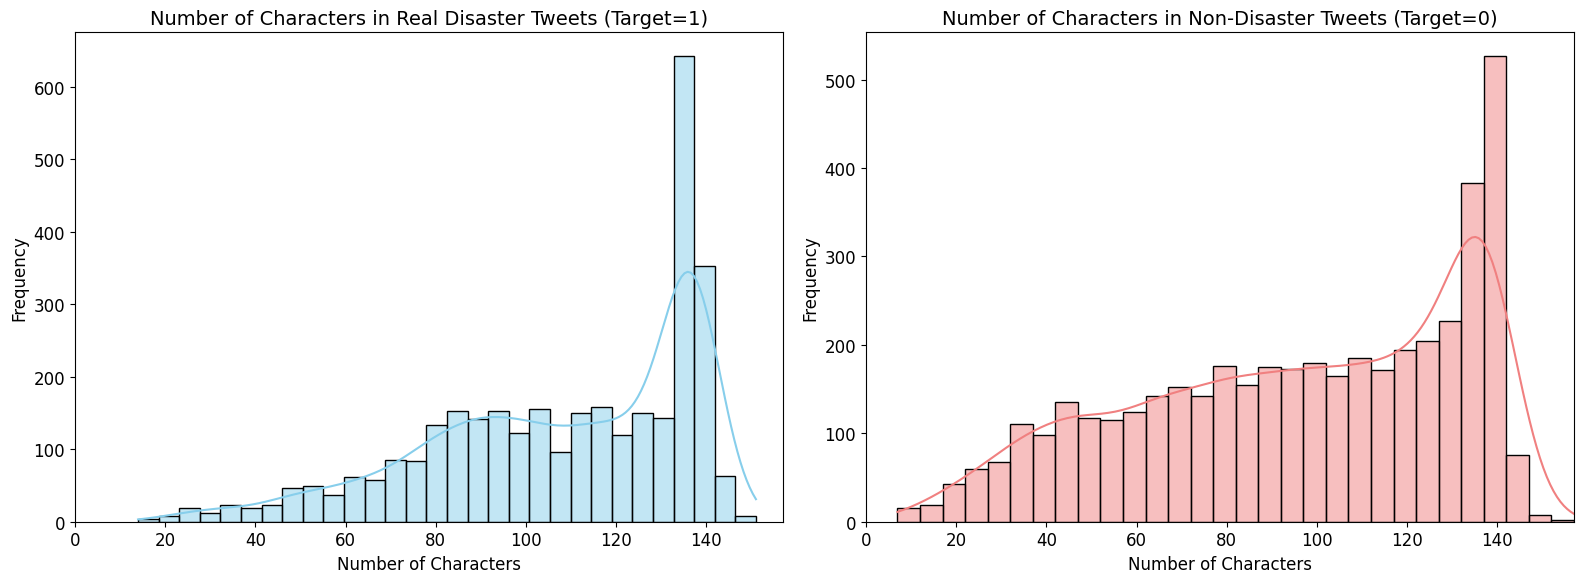

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a larger default font size for better readability
plt.rcParams.update({'font.size': 12})

# Create the figure and a set of subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot histogram for target=1 (Real Disasters)
sns.histplot(real_disasters_df['char_count'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Number of Characters in Real Disaster Tweets (Target=1)', fontsize=14)
axes[0].set_xlabel('Number of Characters', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Plot histogram for target=0 (Non-Disasters)
sns.histplot(non_disasters_df['char_count'], bins=30, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Number of Characters in Non-Disaster Tweets (Target=0)', fontsize=14)
axes[1].set_xlabel('Number of Characters', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

# Ensure consistent x-axis limits for better comparison
max_char_count = max(real_disasters_df['char_count'].max(), non_disasters_df['char_count'].max())
for ax in axes:
    ax.set_xlim(0, max_char_count)

plt.tight_layout()
plt.show()

##Data Preparation
For effective classification, it is essential to reduce noise in the textual data. An inspection of the top 20 most frequent words revealed typical stop words that contribute little to the meaning of the text. To achieve better consistency for subsequent modeling steps, the following transformations were applied:
- All text was converted to lowercase characters.
- Punctuation and special characters were removed.
- The stop words library from NLTK was downloaded and applied to remove such words from both the text and keyword columns.
- The text and keyword columns were combined into a single feature.
- Based on the hypothesis that keywords carry special significance in tweet classification, each keyword was duplicated to boost its weight in the model. While testing this assumption was beyond the scope of the current analysis, it is recommended to further explore the true importance of keywords and evaluate whether boosting improves classification performance—and, if so, to determine the optimal level of boosting.

In [47]:
from collections import Counter
import itertools

# Combine all text into a single list of words
all_words = list(itertools.chain.from_iterable(train_df['text'].apply(lambda x: str(x).split()).tolist()))

# Count word frequencies
word_counts = Counter(all_words)

# Get the top 20 most common words
top_20_words = word_counts.most_common(20)

print("Top 20 most frequent words in the 'text' column:")
for word, count in top_20_words:
    print(f"{word}: {count}")

Top 20 most frequent words in the 'text' column:
the: 2575
a: 1845
to: 1805
in: 1757
of: 1722
and: 1302
I: 1197
for: 820
is: 814
on: 773
-: 763
you: 632
The: 552
my: 549
with: 508
that: 492
at: 485
by: 469
it: 433
from: 372


In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

data_staging_1 = train_df.copy()

# 2. Convert the 'text' column in data_staging_1 to lowercase.
data_staging_1['text'] = data_staging_1['text'].str.lower()

# 3. Fill any missing values in the 'keyword' column with an empty string, then convert to lowercase.
data_staging_1['keyword'] = data_staging_1['keyword'].fillna('').str.lower()

# 4. Define a function to remove punctuation from a given text string. Apply this function.
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

data_staging_1['text'] = data_staging_1['text'].apply(remove_punctuation)
data_staging_1['keyword'] = data_staging_1['keyword'].apply(remove_punctuation)

# 5. Define a function to remove special characters from a given text string. Apply this function.
def remove_special_characters(text):
    # Keep alphanumeric characters and spaces
    return re.sub(r'[^a-z0-9\s]', '', text)

data_staging_1['text'] = data_staging_1['text'].apply(remove_special_characters)
data_staging_1['keyword'] = data_staging_1['keyword'].apply(remove_special_characters)

# 6. Define a function to remove common English stop words. Apply this function.
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    return ' '.join([word for word in str(text).split() if word not in stop_words])

data_staging_1['text'] = data_staging_1['text'].apply(remove_stopwords)
data_staging_1['keyword'] = data_staging_1['keyword'].apply(remove_stopwords)

print("Data cleaning and preprocessing steps completed for 'text' and 'keyword' columns.")
print(data_staging_1[['text', 'keyword']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Data cleaning and preprocessing steps completed for 'text' and 'keyword' columns.
                                                text keyword
0       deeds reason earthquake may allah forgive us        
1              forest fire near la ronge sask canada        
2  residents asked shelter place notified officer...        
3  13000 people receive wildfires evacuation orde...        
4  got sent photo ruby alaska smoke wildfires pou...        


In [52]:
boost_factor = 2

data_staging_1['combined_text'] = data_staging_1.apply(lambda row:
    ' '.join([row['text']] + [row['keyword']] * boost_factor), axis=1)

display(data_staging_1[data_staging_1['keyword'] != ''][['text', 'keyword', 'combined_text']].head())

,text,keyword,combined_text
31,bbcmtd wholesale markets ablaze httptcolhyxeohy6c,ablaze,bbcmtd wholesale markets ablaze httptcolhyxeoh...
32,always try bring heavy metal rt httptcoyao1e0xngw,ablaze,always try bring heavy metal rt httptcoyao1e0x...
33,africanbaze breaking newsnigeria flag set abla...,ablaze,africanbaze breaking newsnigeria flag set abla...
34,crying set ablaze,ablaze,crying set ablaze ablaze ablaze
35,plus side look sky last night ablaze httptcoqq...,ablaze,plus side look sky last night ablaze httptcoqq...


In [53]:
data_staging_2 = data_staging_1.copy()
data_staging_2 = data_staging_2.drop(columns=['keyword', 'location'])
display(data_staging_2.head())

,id,text,target,combined_text
0,1,deeds reason earthquake may allah forgive us,1,deeds reason earthquake may allah forgive us
1,4,forest fire near la ronge sask canada,1,forest fire near la ronge sask canada
2,5,residents asked shelter place notified officer...,1,residents asked shelter place notified officer...
3,6,13000 people receive wildfires evacuation orde...,1,13000 people receive wildfires evacuation orde...
4,7,got sent photo ruby alaska smoke wildfires pou...,1,got sent photo ruby alaska smoke wildfires pou...


#Initial LSTM model

##Text Vectoriztion
Several articles were studied concerning the text preparation for NLP modelling. For example, this article proved to be useful: https://www.kdnuggets.com/2020/03/tensorflow-keras-tokenization-text-data-prep.html

In Keras-based NLP workflows, the *Tokenizer*, *pad_sequences*, and *Embedding* layers work together to transform raw text into a format suitable for deep learning models:
- The **Tokenizer** first builds a vocabulary from the training corpus and converts each text into sequences of integer indices, where each index represents a word.
- Since neural networks require inputs of uniform length in packages like Keras for efficient optimization, **pad_sequences** ensures consistency by padding shorter sequences with zeros or truncating longer ones to a fixed length.
- Finally, the **Embedding** layer maps these integer indices to dense, low-dimensional vectors that capture semantic relationships between words.

This pipeline effectively bridges the gap between unstructured text and numerical representations, enabling models such as LSTM to learn meaningful patterns.


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

data_staging_3 = data_staging_2.copy()

# Define features (X) and target (y)
X = data_staging_3['combined_text']
y = data_staging_3['target']

# 2. Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

# 3. Initialize a Tokenizer
num_words = 10000  # Maximum number of words to keep
oov_token = '<unk>' # Out-of-vocabulary token
tokenizer = Tokenizer(num_words=num_words, oov_token=oov_token)

# 4. Fit the tokenizer on the 'combined_text' column of the training set
tokenizer.fit_on_texts(X_train)

# 5. Convert both training and validation 'combined_text' into sequences of integers
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_val_sequences = tokenizer.texts_to_sequences(X_val)

# 6. Determine the maximum sequence length from the training sequences
maxlen = max(len(x) for x in X_train_sequences)
print(f"\nMaximum sequence length: {maxlen}")

# 7. Pad both the training and validation sequences
X_train_padded = pad_sequences(X_train_sequences, maxlen=maxlen, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=maxlen, padding='post', truncating='post')

# 8. Print the shapes of the padded sequences to verify the output
print(f"\nShape of padded training sequences (X_train_padded): {X_train_padded.shape}")
print(f"Shape of padded validation sequences (X_val_padded): {X_val_padded.shape}")

print("\nText tokenization and padding completed.")

Shape of X_train: (6090,)
Shape of X_val: (1523,)
Shape of y_train: (6090,)
Shape of y_val: (1523,)

Maximum sequence length: 27

Shape of padded training sequences (X_train_padded): (6090, 27)
Shape of padded validation sequences (X_val_padded): (1523, 27)

Text tokenization and padding completed.


In [56]:
display(X_train_padded[0])

array([5671, 3742, 2295,  249,  462,  320,   22, 1951, 3743, 1058,   61,
       3744, 3745, 5672,   61,   61,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0], dtype=int32)

## Model Architecture
- **Embedding layer**: This is the first layer. It takes the integer-encoded tweet sequences and transforms each word index into a 100-dimensional dense vector. It automatically handles input_length based on the padded sequences.
- **LSTM layer**: This layer has 128 units (neurons). dropout=0.2 applies dropout to the inputs of the LSTM layer, and recurrent_dropout=0.2 applies dropout to the recurrent connections of the LSTM layer. Both are regularization techniques to prevent overfitting during training.
- **Dropout layer**: An additional dropout layer with a rate of 0.5 is added after the LSTM layer. This means 50% of the neurons from the previous layer will be randomly deactivated during each training step.
- **Dense output layer**: This is the final layer with 1 unit and a sigmoid activation function.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Define vocabulary size and embedding dimension
vocabulary_size = num_words # From previous step (Tokenizer num_words)
embedding_dim = 100 # Dimension for word embeddings

# Define the LSTM model
model = Sequential()
model.add(Embedding(input_dim=vocabulary_size, output_dim=embedding_dim)) # Removed input_length
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2)) # LSTM layer with dropout
model.add(Dropout(0.5)) # Dropout layer to prevent overfitting
model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("LSTM Model Architecture:")
model.summary()
print("\nLSTM model defined and compiled successfully.")

LSTM Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


LSTM model defined and compiled successfully.


In [ ]:
epochs = 10
batch_size = 32

# Train the model
history = model.fit(X_train_padded, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val_padded, y_val))

print("LSTM model training completed. Training history stored.")

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - accuracy: 0.6136 - loss: 0.6372 - val_accuracy: 0.7873 - val_loss: 0.4837
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.8573 - loss: 0.3784 - val_accuracy: 0.7932 - val_loss: 0.4735
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.9061 - loss: 0.2787 - val_accuracy: 0.7873 - val_loss: 0.4889
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.9260 - loss: 0.2302 - val_accuracy: 0.7846 - val_loss: 0.5433
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.9388 - loss: 0.1822 - val_accuracy: 0.7715 - val_loss: 0.6575
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - accuracy: 0.9434 - loss: 0.1689 - val_accuracy: 0.7649 - val_loss: 0.7836
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.9524 - loss: 0.1338 - val_accuracy: 0.7708 - val_loss: 0.8766
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - accuracy: 0.9652 - loss: 0.1006 -

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# 1. Evaluate the model on the validation set
loss, accuracy = model.evaluate(X_val_padded, y_val, verbose=0)
print(f'Validation Loss: {loss:.4f}')
print(f'Validation Accuracy: {accuracy:.4f}')

# 2. Predict probabilities on the validation set
y_pred_proba = model.predict(X_val_padded)

# 3. Convert predicted probabilities to binary predictions
y_pred = np.where(y_pred_proba > 0.5, 1, 0)

# 5. Calculate Precision
precision = precision_score(y_val, y_pred)
print(f'Precision: {precision:.4f}')

# 6. Calculate Recall
recall = recall_score(y_val, y_pred)
print(f'Recall: {recall:.4f}')

# 7. Calculate F1-score
f1 = f1_score(y_val, y_pred)
print(f'F1-score: {f1:.4f}')

print("Model evaluation on validation set completed.")

Validation Loss: 1.1171
Validation Accuracy: 0.7406
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step
Precision: 0.6693
Recall: 0.7735
F1-score: 0.7177
Model evaluation on validation set completed.


In [ ]:
print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

Validation Accuracy: 0.7406
Precision: 0.6693
Recall: 0.7735
F1-score: 0.7177


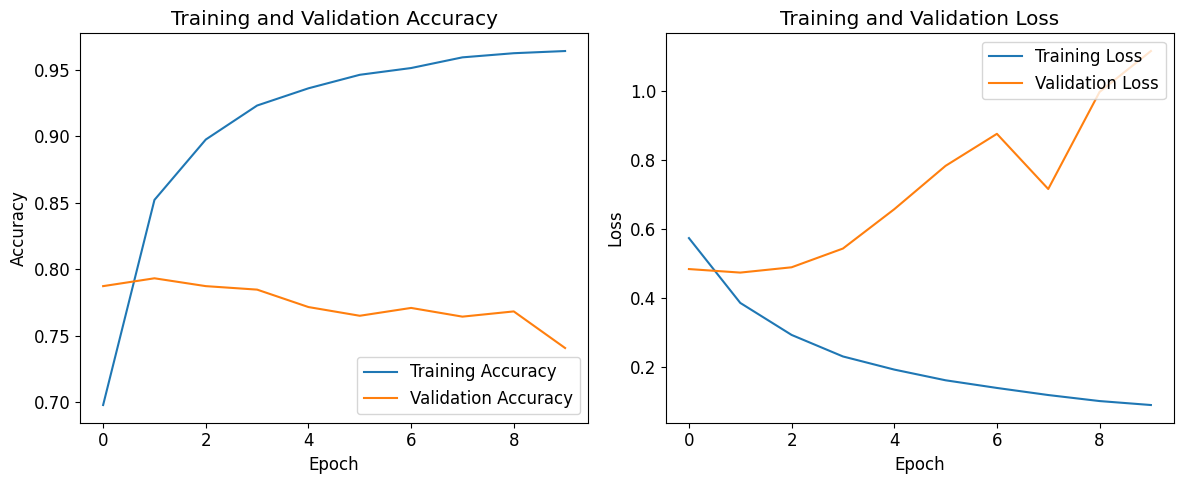

Training history visualization completed.


In [ ]:
import matplotlib.pyplot as plt

# Get training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot Training and Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

print("Training history visualization completed.")

##Initial Model Summary
The **initial LSTM model exhibited overfitting** from the very beginning. Minor adjustments to dropout rates, learning rate, and model complexity did not yield significant improvements. During training, validation accuracy steadily declined while training accuracy continued to rise, surpassing 95%. Despite these challenges, the model achieved a validation accuracy of approximately 75% and an F1 score of 0.72.

Analysis of the confusion matrix indicates that **the model struggled more with tweets unrelated to actual disasters**: out of 874 such cases, 248 were misclassified (28%). **Performance was comparatively better on disaster-related tweets**, where 147 out of 647 cases were misclassified (23%).



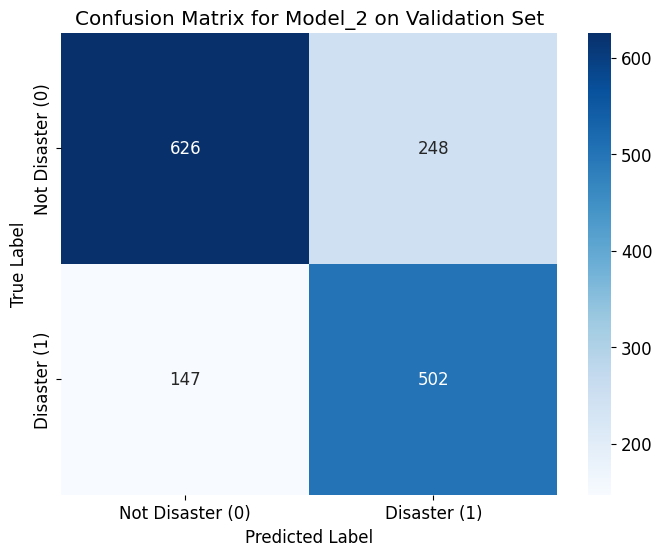

Confusion matrix for Model_2 on the validation set displayed.


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for Model_2 on the validation set
cm_model_1 = confusion_matrix(y_val, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_model_1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Disaster (0)', 'Disaster (1)'],
            yticklabels=['Not Disaster (0)', 'Disaster (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Model_2 on Validation Set')
plt.show()

print("Confusion matrix for Model_2 on the validation set displayed.")

#Updated LSTM Model

##Model Architecture
While refining the original model, it was observed that increasing model complexity could significantly improve performance. At the same time, the challenge of severe overfitting required more aggressive use of regularization, primarily through Dropout layers. The final architecture was structured as follows:
- **First LSTM Layer**: Contains 256 units. dropout=0.2 applies dropout to the inputs, while recurrent_dropout=0.2 applies dropout to the recurrent connections, both helping to reduce overfitting. Importantly, return_sequences=True is set so that the layer outputs the full sequence of hidden states, which is necessary for feeding into the subsequent LSTM layer.
- **First Dropout Layer**: A Dropout layer with a rate of 0.5 follows the first LSTM. This randomly sets 50% of inputs to zero during training, further mitigating overfitting.
- **Second LSTM Layer**: Also configured with 256 units, dropout=0.2, and recurrent_dropout=0.2. Since it does not feed into another recurrent layer, return_sequences defaults to False, meaning only the final hidden state is output.
- **Second Dropout Layer**: Another Dropout layer with a rate of 0.5 is applied after the second LSTM layer to maintain regularization.
- **Dense Output Layer**: The final classification layer consists of a single unit with a sigmoid activation function, producing a probability between 0 and 1 for disaster versus non-disaster classification.

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Reuse vocabulary_size and embedding_dim from previous steps
vocabulary_size = num_words # From previous step (Tokenizer num_words)
embedding_dim = 100 # Dimension for word embeddings

# Initialize a Sequential model and name it model_2
model_2 = Sequential()

# Add an Embedding layer to model_2
model_2.add(Embedding(input_dim=vocabulary_size, output_dim=embedding_dim))

# Add the first LSTM layer with 256 units, dropout, recurrent_dropout, and return_sequences=True
model_2.add(LSTM(256, dropout=0.2, recurrent_dropout=0.2, return_sequences=True))

# Add a Dropout layer with a rate of 0.5
model_2.add(Dropout(0.5))

# Add the second LSTM layer with 256 units, dropout, and recurrent_dropout
model_2.add(LSTM(256, dropout=0.2, recurrent_dropout=0.2))

# Add another Dropout layer with a rate of 0.5
model_2.add(Dropout(0.5))

# Add a Dense output layer with 1 unit and activation='sigmoid'
model_2.add(Dense(1, activation='sigmoid'))

# Instantiate an Adam optimizer with a learning_rate=0.001
adam_optimizer = Adam(learning_rate=0.001)

# Compile model_2
model_2.compile(optimizer=adam_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print the model_2 summary to verify its architecture
print("Model_2 Architecture with Enhanced Design:")
model_2.summary()
print("\nModel_2 defined and compiled successfully.")

Model_2 Architecture with Enhanced Design:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Model_2 defined and compiled successfully.


In [42]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Instantiate a ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Monitor validation loss
    factor=0.2,          # Reduce learning rate by 80% (new_lr = current_lr * factor)
    patience=2,          # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.00001,      # Minimum learning rate
    verbose=1            # Print messages when learning rate is reduced
)

print("ReduceLROnPlateau callback defined successfully.")

ReduceLROnPlateau callback defined successfully.


In [43]:
epochs = 100 # Set a sufficiently large number of epochs, as callbacks will manage early stopping/LR decay
batch_size = 32

# Train Model_2 with EarlyStopping and ReduceLROnPlateau callbacks
history_model_2 = model_2.fit(
    X_train_padded,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_padded, y_val),
    callbacks=[early_stopping, reduce_lr]
)

print("Model_2 training with EarlyStopping and ReduceLROnPlateau callbacks completed. Training history stored in history_model_2.")

Epoch 1/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 118s 564ms/step - accuracy: 0.6496 - loss: 0.6157 - val_accuracy: 0.8011 - val_loss: 0.4691 - learning_rate: 0.0010
Epoch 2/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 104s 542ms/step - accuracy: 0.8664 - loss: 0.3606 - val_accuracy: 0.7971 - val_loss: 0.4710 - learning_rate: 0.0010
Epoch 3/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.9081 - loss: 0.2735
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
191/191 ━━━━━━━━━━━━━━━━━━━━ 105s 552ms/step - accuracy: 0.9080 - loss: 0.2736 - val_accuracy: 0.7787 - val_loss: 0.4742 - learning_rate: 0.0010
Epoch 4/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 106s 557ms/step - accuracy: 0.9242 - loss: 0.2287 - val_accuracy: 0.7833 - val_loss: 0.5514 - learning_rate: 2.0000e-04
Model_2 training with EarlyStopping and ReduceLROnPlateau callbacks completed. Training history stored in history_model_2.


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# 1. Evaluate the model_2 on the validation set
loss_model_2, accuracy_model_2 = model_2.evaluate(X_val_padded, y_val, verbose=0)
print(f'Model_2 Validation Loss: {loss_model_2:.4f}')
print(f'Model_2 Validation Accuracy: {accuracy_model_2:.4f}')

# 2. Predict probabilities on the validation set
y_pred_proba_model_2 = model_2.predict(X_val_padded)

# 3. Convert predicted probabilities to binary predictions
y_pred_model_2 = np.where(y_pred_proba_model_2 > 0.5, 1, 0)

# 4. Calculate Precision
precision_model_2 = precision_score(y_val, y_pred_model_2)
print(f'Model_2 Precision: {precision_model_2:.4f}')

# 5. Calculate Recall
recall_model_2 = recall_score(y_val, y_pred_model_2)
print(f'Model_2 Recall: {recall_model_2:.4f}')

# 6. Calculate F1-score
f1_model_2 = f1_score(y_val, y_pred_model_2)
print(f'Model_2 F1-score: {f1_model_2:.4f}')

print("Model_2 evaluation on validation set completed.")

Model_2 Validation Loss: 0.4691
Model_2 Validation Accuracy: 0.8011
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step
Model_2 Precision: 0.8604
Model_2 Recall: 0.6364
Model_2 F1-score: 0.7316
Model_2 evaluation on validation set completed.


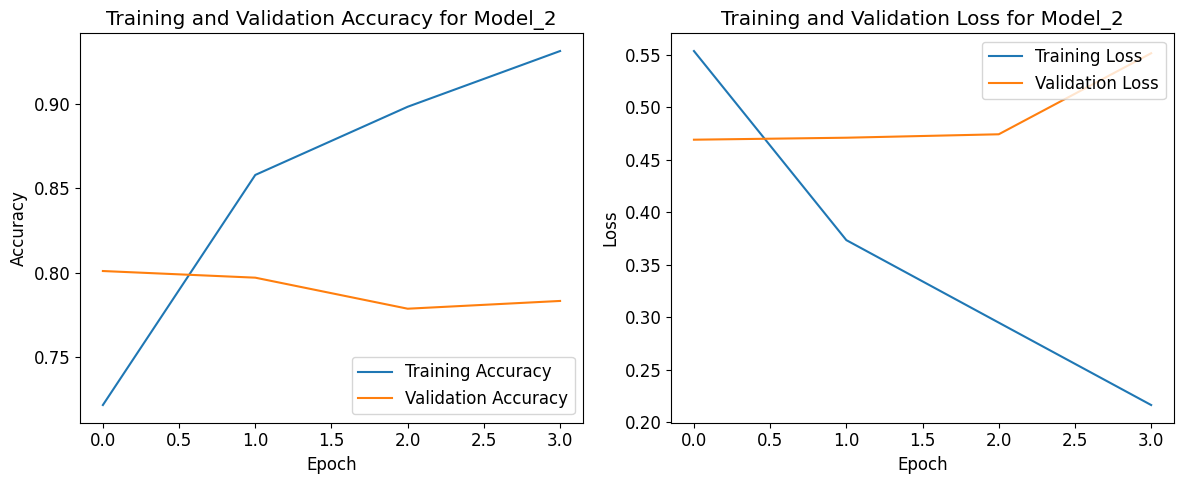

Model_2 training history visualization completed.


In [45]:
import matplotlib.pyplot as plt

# Get training history for Model_2
acc_model_2 = history_model_2.history['accuracy']
val_acc_model_2 = history_model_2.history['val_accuracy']
loss_model_2 = history_model_2.history['loss']
val_loss_model_2 = history_model_2.history['val_loss']

epochs_range_model_2 = range(len(acc_model_2))

plt.figure(figsize=(12, 5))

# Plot Training and Validation Accuracy for Model_2
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs_range_model_2, acc_model_2, label='Training Accuracy')
plt.plot(epochs_range_model_2, val_acc_model_2, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy for Model_2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot Training and Validation Loss for Model_2
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs_range_model_2, loss_model_2, label='Training Loss')
plt.plot(epochs_range_model_2, val_loss_model_2, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss for Model_2')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

print("Model_2 training history visualization completed.")

#Model Comparison and Project Conclusion
**Challenges**

Unfortunately, overfitting persisted in the second model, as validation accuracy continued to decline while training accuracy steadily increased.

Nonetheless, the updated model achieved stronger overall performance, reaching a validation accuracy of 80% and an F1-score of 0.73.

**Best Model**

The confusion matrix analysis revealed a key trade-off. Compared to the original model, the updated model showed a noticeable weakness in classifying actual disaster tweets: 36% were misclassified, versus 23% in the first model. On the other hand, the updated model performed substantially better on non-disaster tweets, misclassifying only 7.6%—nearly four times fewer errors than the first model.

Without additional context, the first model might be preferred for its simplicity and more balanced error distribution, despite being weaker overall. In practice, the choice would depend on application priorities. For example, in a disaster detection system designed to crowdsource urgent information, minimizing false negatives (missed disasters) would be more critical than reducing false positives.

In this competition, however, the decision was guided by an objective metric. **Kaggle’s verification showed the second model outperforming the first by two percentage points, and it was therefore selected as the “best model.”**

**Suggestions**
- The second model demonstrates strong potential for classifying non-disaster tweets. With additional resources, further improvements in this area can be expected.
- Overfitting remains a significant limitation, reflecting the challenge of training highly complex models with relatively small datasets. Expanding the dataset volume would likely improve generalization.
- Transfer learning offers a promising alternative: leveraging pre-trained models trained on large-scale datasets and fine-tuning them with task-specific layers could reduce overfitting and enhance performance.

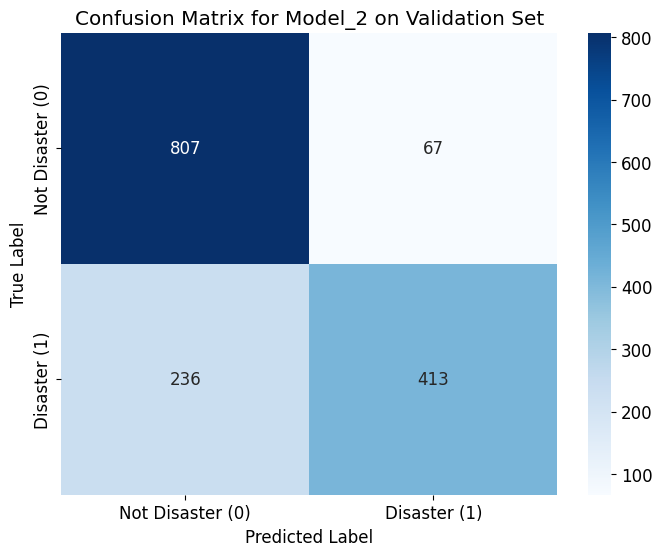

Confusion matrix for Model_2 on the validation set displayed.


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for Model_2 on the validation set
cm_model_2 = confusion_matrix(y_val, y_pred_model_2)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_model_2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Disaster (0)', 'Disaster (1)'],
            yticklabels=['Not Disaster (0)', 'Disaster (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Model_2 on Validation Set')
plt.show()

print("Confusion matrix for Model_2 on the validation set displayed.")

#Generating Submission File

In [62]:
import re
import string
import nltk
import pandas as pd
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Ensure stopwords are downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# --- 1. Preprocess test_df ---#
# Create a copy of test_df for preprocessing
test_staging_1 = test_df.copy()

# Convert the 'text' column to lowercase.
test_staging_1['text'] = test_staging_1['text'].str.lower()

# Fill any missing values in the 'keyword' column with an empty string, then convert to lowercase.
test_staging_1['keyword'] = test_staging_1['keyword'].fillna('').str.lower()

# Define a function to remove punctuation from a given text string. Apply this function.
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

test_staging_1['text'] = test_staging_1['text'].apply(remove_punctuation)
test_staging_1['keyword'] = test_staging_1['keyword'].apply(remove_punctuation)

# Define a function to remove special characters from a given text string. Apply this function.
def remove_special_characters(text):
    # Keep alphanumeric characters and spaces
    return re.sub(r'[^a-z0-9\s]', '', text)

test_staging_1['text'] = test_staging_1['text'].apply(remove_special_characters)
test_staging_1['keyword'] = test_staging_1['keyword'].apply(remove_special_characters)

# Define a function to remove common English stop words. Apply this function.
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    return ' '.join([word for word in str(text).split() if word not in stop_words])

test_staging_1['text'] = test_staging_1['text'].apply(remove_stopwords)
test_staging_1['keyword'] = test_staging_1['keyword'].apply(remove_stopwords)

# Engineer a new feature by boosting and combining 'keyword' with 'text'
# Using the same boost_factor defined earlier (assumed to be 2)
test_staging_1['combined_text'] = test_staging_1.apply(lambda row:
    ' '.join([row['text']] + [row['keyword']] * boost_factor), axis=1)

print("Test data cleaning and preprocessing completed.")

# --- 2. Tokenize and Pad test_df ---#
# Convert 'combined_text' into sequences of integers using the *already fitted* tokenizer
X_test_sequences = tokenizer.texts_to_sequences(test_staging_1['combined_text'])

# Pad the test sequences to the same maxlen determined from training data
X_test_padded = pad_sequences(X_test_sequences, maxlen=maxlen, padding='post', truncating='post')

print(f"Shape of padded test sequences (X_test_padded): {X_test_padded.shape}")

# --- 3. Make predictions using model_2 ---#
y_pred_proba_test = model.predict(X_test_padded)

# --- 4. Convert predicted probabilities to binary predictions ---#
y_pred_test = np.where(y_pred_proba_test > 0.5, 1, 0)

# --- 5. Create and save submission file ---#
submission_df = pd.DataFrame({'id': test_df['id'], 'target': y_pred_test.flatten()})

# Define the output directory and file path
output_dir_submission = '/content/nlp_data/submission'
submission_file_path = f'{output_dir_submission}/submission_2.csv'

# Create the output directory if it doesn't exist
!mkdir -p {output_dir_submission}

# Save the submission file
submission_df.to_csv(submission_file_path, index=False)

print(f"Predictions made and saved to {submission_file_path}")
print("First 5 rows of the submission file:")
print(submission_df.head())

Test data cleaning and preprocessing completed.
Shape of padded test sequences (X_test_padded): (3263, 27)
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step
Predictions made and saved to /content/nlp_data/submission/submission_2.csv
First 5 rows of the submission file:
   id  target
0   0       0
1   2       1
2   3       1
3   9       1
4  11       1
